<a href="https://colab.research.google.com/github/poeticinspiired/-A-Python-API/blob/master/neuron_networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

BIKE DELIVERY TIME PREDICTION

Training Data:
  Distance: 1.0 miles → Time: 6.96 minutes
  Distance: 2.0 miles → Time: 12.11 minutes
  Distance: 3.0 miles → Time: 16.77 minutes
  Distance: 4.0 miles → Time: 22.21 minutes

TRAINING LINEAR MODEL
Epoch [200/1000], Loss: 0.0311
Epoch [400/1000], Loss: 0.0271
Epoch [600/1000], Loss: 0.0259
Epoch [800/1000], Loss: 0.0256
Epoch [1000/1000], Loss: 0.0255

TRAINING NEURAL NETWORK
Epoch [200/1000], Loss: 31.8619
Epoch [400/1000], Loss: 31.7900
Epoch [600/1000], Loss: 31.7900
Epoch [800/1000], Loss: 31.7900
Epoch [1000/1000], Loss: 31.7900

PREDICTIONS FOR 7.0 MILES

Linear Model Prediction: 37.17 minutes
Neural Network Prediction: 14.51 minutes
Difference: 22.66 minutes

MODEL ANALYSIS

Linear Model Equation: time = 5.0353 × distance + 1.9267
  Interpretation: ~5.04 minutes per mile + 1.93 minute base time

Model Complexity:
  Linear Model: 2 parameters
  Neural Network: 57 parameters (Architecture: 1→8→4→1)


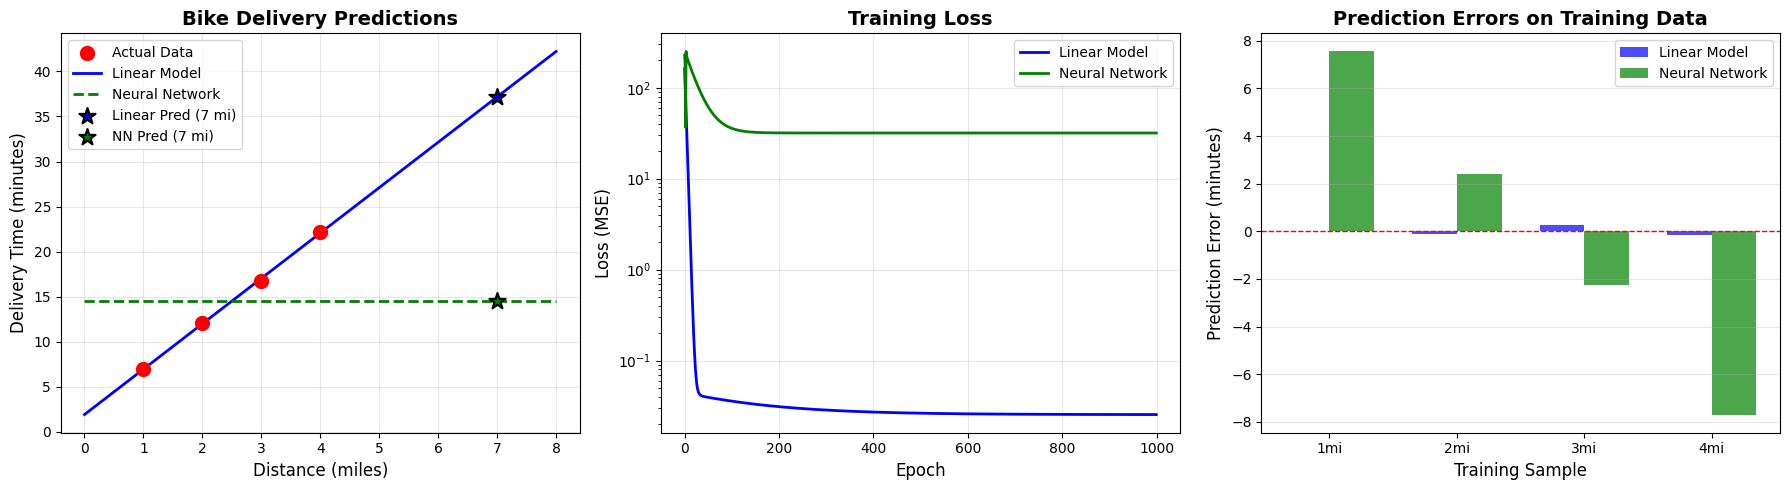


WHEN TO USE EACH MODEL

LINEAR MODEL:
  ✓ Best for: Simple, linear relationships (like this bike delivery data)
  ✓ Advantages: Easy to interpret, fast to train, needs less data
  ✓ Use when: Relationship is approximately y = mx + b

NEURAL NETWORK:
  ✓ Best for: Complex, non-linear relationships
  ✓ Advantages: Can learn complex patterns, flexible
  ✓ Use when: Relationship has curves, interactions, or multiple factors

FOR THIS DATASET:
  Both models perform similarly because delivery time increases linearly
  with distance. The linear model is preferred here for its simplicity!



In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

# Set random seed for reproducibility
torch.manual_seed(42)

# ============================================================================
# DATA PREPARATION
# ============================================================================
# Distance in miles for recent bike deliveries
distance = torch.tensor([[1.0], [2.0], [3.0], [4.0]], dtype=torch.float32)

# Corresponding delivery times in minutes
time = torch.tensor([[6.96], [12.11], [16.77], [22.21]], dtype=torch.float32)

print("="*70)
print("BIKE DELIVERY TIME PREDICTION")
print("="*70)
print("\nTraining Data:")
for i in range(len(distance)):
    print(f"  Distance: {distance[i].item():.1f} miles → Time: {time[i].item():.2f} minutes")

# ============================================================================
# LINEAR MODEL (Simple regression: y = mx + b)
# ============================================================================
print("\n" + "="*70)
print("TRAINING LINEAR MODEL")
print("="*70)

# Create a linear model: one input (distance) → one output (time)
linear_model = nn.Sequential(nn.Linear(1, 1))

# Define loss function (Mean Squared Error) and optimizer
loss_fn = nn.MSELoss()
optimizer_linear = optim.SGD(linear_model.parameters(), lr=0.01)

# Store losses for plotting
linear_losses = []

# Training loop for linear model
num_epochs = 1000
for epoch in range(num_epochs):
    # Forward pass: compute predicted time
    predictions = linear_model(distance)

    # Compute loss (difference between predictions and actual values)
    loss = loss_fn(predictions, time)
    linear_losses.append(loss.item())

    # Backward pass: compute gradients
    optimizer_linear.zero_grad()  # Clear previous gradients
    loss.backward()  # Calculate gradients

    # Update weights using gradient descent
    optimizer_linear.step()

    # Print progress every 200 epochs
    if (epoch + 1) % 200 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

# ============================================================================
# NEURAL NETWORK MODEL (with hidden layers)
# ============================================================================
print("\n" + "="*70)
print("TRAINING NEURAL NETWORK")
print("="*70)

# Create a neural network with:
# - Input layer: 1 neuron (distance)
# - Hidden layer 1: 8 neurons with ReLU activation
# - Hidden layer 2: 4 neurons with ReLU activation
# - Output layer: 1 neuron (time)
neural_network = nn.Sequential(
    nn.Linear(1, 8),      # Input → Hidden layer 1
    nn.ReLU(),            # Activation function (introduces non-linearity)
    nn.Linear(8, 4),      # Hidden layer 1 → Hidden layer 2
    nn.ReLU(),            # Activation function
    nn.Linear(4, 1)       # Hidden layer 2 → Output
)

# Define optimizer for neural network
optimizer_nn = optim.SGD(neural_network.parameters(), lr=0.01)

# Store losses for plotting
nn_losses = []

# Training loop for neural network
for epoch in range(num_epochs):
    # Forward pass
    predictions = neural_network(distance)

    # Compute loss
    loss = loss_fn(predictions, time)
    nn_losses.append(loss.item())

    # Backward pass
    optimizer_nn.zero_grad()
    loss.backward()

    # Update weights
    optimizer_nn.step()

    # Print progress every 200 epochs
    if (epoch + 1) % 200 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

# ============================================================================
# MAKE PREDICTIONS
# ============================================================================
print("\n" + "="*70)
print("PREDICTIONS FOR 7.0 MILES")
print("="*70)

distance_to_predict = 7.0
distance_tensor = torch.tensor([[distance_to_predict]], dtype=torch.float32)

# Make predictions with both models
with torch.no_grad():
    linear_prediction = linear_model(distance_tensor)
    nn_prediction = neural_network(distance_tensor)

    print(f'\nLinear Model Prediction: {linear_prediction.item():.2f} minutes')
    print(f'Neural Network Prediction: {nn_prediction.item():.2f} minutes')
    print(f'Difference: {abs(linear_prediction.item() - nn_prediction.item()):.2f} minutes')

# ============================================================================
# MODEL ANALYSIS
# ============================================================================
print("\n" + "="*70)
print("MODEL ANALYSIS")
print("="*70)

# Linear model parameters
weight = linear_model[0].weight.item()
bias = linear_model[0].bias.item()
print(f'\nLinear Model Equation: time = {weight:.4f} × distance + {bias:.4f}')
print(f'  Interpretation: ~{weight:.2f} minutes per mile + {bias:.2f} minute base time')

# Neural network info
total_params = sum(p.numel() for p in neural_network.parameters())
linear_params = sum(p.numel() for p in linear_model.parameters())
print(f'\nModel Complexity:')
print(f'  Linear Model: {linear_params} parameters')
print(f'  Neural Network: {total_params} parameters (Architecture: 1→8→4→1)')

# ============================================================================
# VISUALIZATIONS
# ============================================================================

# Create a figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Generate smooth prediction line
distance_range = torch.linspace(0, 8, 100).reshape(-1, 1)
with torch.no_grad():
    linear_pred_range = linear_model(distance_range).numpy()
    nn_pred_range = neural_network(distance_range).numpy()

# Plot 1: Model Predictions vs Actual Data
ax1 = axes[0]
ax1.scatter(distance.numpy(), time.numpy(), color='red', s=100, label='Actual Data', zorder=3)
ax1.plot(distance_range.numpy(), linear_pred_range, 'b-', linewidth=2, label='Linear Model')
ax1.plot(distance_range.numpy(), nn_pred_range, 'g--', linewidth=2, label='Neural Network')
ax1.scatter([distance_to_predict], [linear_prediction.item()], color='blue',
            s=150, marker='*', edgecolors='black', linewidth=1.5,
            label=f'Linear Pred (7 mi)', zorder=4)
ax1.scatter([distance_to_predict], [nn_prediction.item()], color='green',
            s=150, marker='*', edgecolors='black', linewidth=1.5,
            label=f'NN Pred (7 mi)', zorder=4)
ax1.set_xlabel('Distance (miles)', fontsize=12)
ax1.set_ylabel('Delivery Time (minutes)', fontsize=12)
ax1.set_title('Bike Delivery Predictions', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Training Loss Over Time
ax2 = axes[1]
ax2.plot(linear_losses, 'b-', linewidth=2, label='Linear Model')
ax2.plot(nn_losses, 'g-', linewidth=2, label='Neural Network')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Loss (MSE)', fontsize=12)
ax2.set_title('Training Loss', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_yscale('log')  # Log scale to see convergence better

# Plot 3: Prediction Error (Residuals)
ax3 = axes[2]
with torch.no_grad():
    linear_residuals = (linear_model(distance) - time).numpy().flatten()
    nn_residuals = (neural_network(distance) - time).numpy().flatten()

x_positions = np.arange(len(distance))
width = 0.35
ax3.bar(x_positions - width/2, linear_residuals, width, label='Linear Model', color='blue', alpha=0.7)
ax3.bar(x_positions + width/2, nn_residuals, width, label='Neural Network', color='green', alpha=0.7)
ax3.axhline(y=0, color='red', linestyle='--', linewidth=1)
ax3.set_xlabel('Training Sample', fontsize=12)
ax3.set_ylabel('Prediction Error (minutes)', fontsize=12)
ax3.set_title('Prediction Errors on Training Data', fontsize=14, fontweight='bold')
ax3.set_xticks(x_positions)
ax3.set_xticklabels([f'{d.item():.0f}mi' for d in distance])
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# ============================================================================
# FINAL COMPARISON
# ============================================================================
print("\n" + "="*70)
print("WHEN TO USE EACH MODEL")
print("="*70)
print("""
LINEAR MODEL:
  ✓ Best for: Simple, linear relationships (like this bike delivery data)
  ✓ Advantages: Easy to interpret, fast to train, needs less data
  ✓ Use when: Relationship is approximately y = mx + b

NEURAL NETWORK:
  ✓ Best for: Complex, non-linear relationships
  ✓ Advantages: Can learn complex patterns, flexible
  ✓ Use when: Relationship has curves, interactions, or multiple factors

FOR THIS DATASET:
  Both models perform similarly because delivery time increases linearly
  with distance. The linear model is preferred here for its simplicity!
""")